In [1]:
import numpy as np
import pandas as pd

from dap_job_quality import BUCKET_NAME, logging
from dap_job_quality.getters import ojo_getters as ojo
from dap_job_quality.getters.data_getters import save_to_s3
from dap_job_quality.getters.keywords import get_keywords
from dap_job_quality.utils import analysis_utils

S3_OUT_PATH = 'job_quality/outputs/random/flourish_tables'

2024-09-23 13:09:20,579 - botocore.credentials - INFO - Found credentials in shared credentials file: ~/.aws/credentials


In [2]:
def prop_table(full_data, grouping_cols = ['knowledge_domain','sector'], prop_col='FLEX_HOURS', sort_by = ['proportion'], ascending=False):
    prop_table = full_data.groupby(grouping_cols).agg({prop_col: sum, 'id': 'size'})
    prop_table[f'non_{prop_col}'] = prop_table['id'] - prop_table[prop_col]
    prop_table['proportion'] = prop_table[prop_col] / prop_table['id']
    return prop_table.sort_values(sort_by, ascending=ascending)

In [3]:
processed_data = pd.read_parquet('s3://open-jobs-lake/job_quality/outputs/random/job_ads_prod_True_n_100000.parquet')

In [4]:
titles = ojo.get_ojo_job_title_sample()
locations = ojo.get_ojo_location_sample()
salaries = ojo.get_ojo_salaries_sample()
skills = ojo.get_ojo_skills_sample()
lookup = get_keywords()

2024-09-23 13:09:28,559 - aiobotocore.credentials - INFO - Found credentials in shared credentials file: ~/.aws/credentials


In [5]:
processed_data = pd.merge(processed_data, lookup[['target_phrase', 'subcategory','dimension']], on='target_phrase', how='left')
processed_data.head()

,id,sentences_split,ngrams,target_phrase,cosine_similarity,subcategory,dimension
0,41624830,"Annual salary starting £28,059.23 with the o...",the opportunity to develop,learning & development,0.669064,L&D,job design and nature of work
1,41624830,"Annual salary starting £28,059.23 with the o...","salary starting £XX,XXX.XX with",salary,0.585201,COMP,pay and benefits
2,41564553,Flexible,Flexible,flexible working,0.779773,FLEX_HOURS,work life balance
3,41701597,Professional training provided with our awar...,Learning and Development Team.,learning & development,0.746505,L&D,job design and nature of work
4,41701597,Professional training provided with our awar...,training provided with our,training,0.787983,L&D,job design and nature of work


In [6]:
dimensions_wide = analysis_utils.create_wide_table(processed_data)
dimensions_wide.head()

subcategory,id,NaN,AUTONOMY,CAREER,CARING,COMP,CONTRACT,DISABILITY,FLEX_HOURS,FLEX_LOC,...,LOC,MISC,M_HEALTH,PERKS,REWARD,SENSE OF PURPOSE,SHIFT,SOCIAL,SPONSORSHIP,VOICE REPRESENTATION
0,41548927,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,41549651,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,41550227,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,41550568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,41550979,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
full_data = pd.merge(titles, dimensions_wide, on='id', how='left')
full_data = pd.merge(locations, full_data, on='id', how='left')

Remove sectors with very few job adverts

<Axes: >

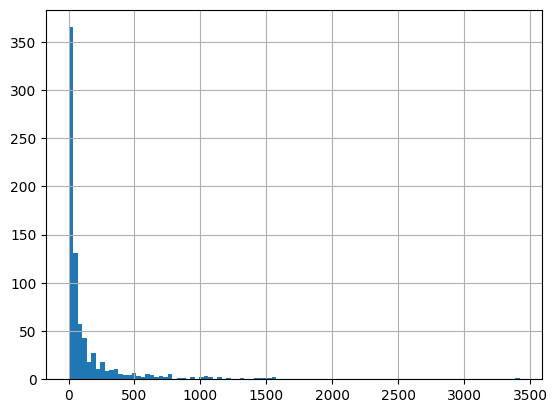

In [8]:
sector_counts = pd.DataFrame(full_data['sector'].value_counts())
sector_counts['count'].hist(bins=100)

In [9]:
sector_counts['count'].describe()

count     767.000000
mean      130.378096
std       260.640676
min         1.000000
25%        12.000000
50%        38.000000
75%       117.000000
max      3419.000000
Name: count, dtype: float64

<Axes: >

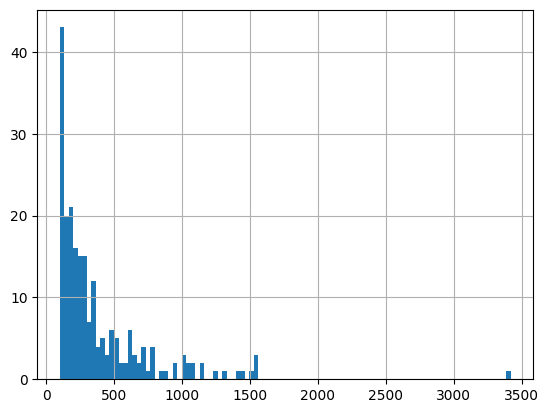

In [10]:
# Exclude sectors with fewer than 100 ads?
sector_counts[sector_counts['count'] > 100]['count'].hist(bins=100)

In [11]:
sector_counts[sector_counts['count'] > 100]['count'].describe()

count     218.000000
mean      386.022936
std       382.726352
min       101.000000
25%       153.500000
50%       255.500000
75%       474.000000
max      3419.000000
Name: count, dtype: float64

In [12]:
sectors_to_remove = sector_counts[sector_counts['count'] < 100].index
full_data = full_data[~full_data['sector'].isin(sectors_to_remove)]

In [13]:
full_data['itl_1_name'].value_counts()

itl_1_name
London                      18493
South East (England)        13705
North West (England)         8710
East of England              8124
South West (England)         7921
West Midlands (England)      6769
Yorkshire and the Humber     5917
East Midlands (England)      5221
Scotland                     2766
Wales                        2096
North East (England)         1928
Northern Ireland              307
Name: count, dtype: int64

In [14]:
# Remove NI because the counts are noticeably lower
full_data = full_data[full_data['itl_1_name'] != 'Northern Ireland']
logging.info(f'N ads remaining after removing (a) underrepresented sectors and (b) Northern Irelands: {len(full_data)}')

2024-09-23 13:09:50,360 - root - INFO - N ads remaining after removing (a) underrepresented sectors and (b) Northern Irelands: 83946


In [15]:
full_data['created'] = pd.to_datetime(full_data['created'])
full_data['year'] = full_data['created'].dt.year
# Check distribution by year
full_data['year'].value_counts()

year
2021    44274
2022    39308
2020      364
Name: count, dtype: int64

In [16]:
columns_to_replace = dimensions_wide.columns[1:] # the first column is the id
# These columns have NaN where there are *no* mentions of JQ dimensions in these job adverts
full_data[columns_to_replace] = full_data[columns_to_replace].fillna(0)
full_data.head()

,id,job_location_raw_x,itl_1_code,itl_1_name,itl_2_code,itl_2_name,itl_3_code,itl_3_name,is_uk,is_large_geo,...,MISC,M_HEALTH,PERKS,REWARD,SENSE OF PURPOSE,SHIFT,SOCIAL,SPONSORSHIP,VOICE REPRESENTATION,year
1,41549201,"Guildford, Surrey",TLJ,South East (England),TLJ2,"Surrey, East and West Sussex",TLJ25,West Surrey,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020
2,41549651,"Paisley, Renfrewshire",TLM,Scotland,TLM8,West Central Scotland,TLM83,"Inverclyde, East Renfrewshire and Renfrewshire",1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020
3,41550227,"Harlow, Essex",TLH,East of England,TLH3,Essex,TLH35,West Essex,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2020
4,41550568,"London, South East England",TLI,London,TLI,London,TLI,London,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020
5,41550979,"Birmingham, West Midlands",TLG,West Midlands (England),TLG3,West Midlands,TLG31,Birmingham,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020


In [17]:
full_data = pd.merge(full_data, salaries, on='id', how='left')
full_data.head()

,id,job_location_raw_x,itl_1_code,itl_1_name,itl_2_code,itl_2_name,itl_3_code,itl_3_name,is_uk,is_large_geo,...,PERKS,REWARD,SENSE OF PURPOSE,SHIFT,SOCIAL,SPONSORSHIP,VOICE REPRESENTATION,year,min_annualised_salary,max_annualised_salary
0,41549201,"Guildford, Surrey",TLJ,South East (England),TLJ2,"Surrey, East and West Sussex",TLJ25,West Surrey,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020,23000.0,26000.0
1,41549651,"Paisley, Renfrewshire",TLM,Scotland,TLM8,West Central Scotland,TLM83,"Inverclyde, East Renfrewshire and Renfrewshire",1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020,25100.0,31649.0
2,41550227,"Harlow, Essex",TLH,East of England,TLH3,Essex,TLH35,West Essex,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2020,NaN,NaN
3,41550568,"London, South East England",TLI,London,TLI,London,TLI,London,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020,69000.0,76000.0
4,41550979,"Birmingham, West Midlands",TLG,West Midlands (England),TLG3,West Midlands,TLG31,Birmingham,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020,12000.0,12000.0


# Which dimensions of job quality are most frequent overall?

## Output for slide 2 - overall proportions of each dimension

In [18]:
full_data.columns
target_dims = ['CAREER','COMP','CONTRACT','FLEX_HOURS','FLEX_LOC','HOURS',
                         'L&D',                 'LEAVE',
                         'LOC', 'PERKS',
                      'SHIFT']

proportions = full_data[target_dims].sum() / len(full_data)
proportions = pd.DataFrame(proportions).reset_index()
proportions.columns = ['subcategory', 'proportion']
proportions

,subcategory,proportion
0,CAREER,0.178662
1,COMP,0.577466
2,CONTRACT,0.341648
3,FLEX_HOURS,0.285529
4,FLEX_LOC,0.150478
5,HOURS,0.528125
6,L&D,0.338896
7,LEAVE,0.288900
8,LOC,0.166011
9,PERKS,0.378160


In [19]:
perk_prop = proportions[proportions['subcategory'].isin(['CAREER', 'FLEX_HOURS', 'FLEX_LOC', 'L&D', 'PERKS'])]
perk_prop['type'] = 'perk'
non_perk_prop = proportions[~proportions['subcategory'].isin(['CAREER', 'FLEX_HOURS', 'FLEX_LOC', 'L&D', 'PERKS'])]
non_perk_prop['type'] = 'non_perk'
overall_prop = pd.concat([perk_prop, non_perk_prop])
overall_prop.to_csv('outputs/overall_proportions.csv', index=False)
save_to_s3(BUCKET_NAME, overall_prop, f'{S3_OUT_PATH}/overall_proportions.csv')
overall_prop

2024-09-23 13:09:50,556 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/outputs/random/flourish_tables/overall_proportions.csv ...


/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_91323/2052708597.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  perk_prop['type'] = 'perk'
/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_91323/2052708597.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_perk_prop['type'] = 'non_perk'


,subcategory,proportion,type
0,CAREER,0.178662,perk
3,FLEX_HOURS,0.285529,perk
4,FLEX_LOC,0.150478,perk
6,L&D,0.338896,perk
9,PERKS,0.378160,perk
1,COMP,0.577466,non_perk
2,CONTRACT,0.341648,non_perk
5,HOURS,0.528125,non_perk
7,LEAVE,0.288900,non_perk
8,LOC,0.166011,non_perk


# The perks most commonly offered were...

In [20]:
perks_df = processed_data[processed_data['id'].isin(full_data['id'].unique())]
perks_df = perks_df[perks_df['subcategory']=='PERKS']
perks_df['target_phrase'] = perks_df['target_phrase'].str.lower()

perks_mapping = {'life assurance':['life insurance', 'life assurance'],
                 'referral scheme': ['refer a friend scheme', 'referral scheme', 'recommend a friend'],
                 'generic benefits': ['benefits', 'flexible benefits platform'],
                 'discounts/vouchers': ['discounts', 'shopping vouchers']}

def map_perk(phrase):
    for k, names in perks_mapping.items():
        if phrase in names:
            return k
    return phrase

perks_df['perk'] = perks_df['target_phrase'].apply(map_perk)
perks_prop = perks_df['perk'].value_counts(normalize=True)
perks_prop = pd.DataFrame(perks_prop).reset_index()
perks_prop

,perk,proportion
0,generic benefits,0.494885
1,discounts/vouchers,0.190747
2,referral scheme,0.110222
3,employee assistance programme,0.068461
4,life assurance,0.064047
5,cycle to work,0.034650
6,clothing allowance,0.024941
7,travel card,0.010092
8,broadband deals,0.001955


## Output for slide 3 - most common perks

In [21]:
save_to_s3(BUCKET_NAME, perks_prop, f'{S3_OUT_PATH}/perks.csv')
perks_prop.to_csv('outputs/perks.csv', index=False)

2024-09-23 13:11:59,038 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/outputs/random/flourish_tables/perks.csv ...


# The occupations most and least likely to offer L&D were...

In [23]:
sector_salaries = full_data.groupby(['sector']).agg({'min_annualised_salary': 'mean'}).reset_index()

In [24]:
sector_l_and_d_prop = prop_table(full_data, grouping_cols = ['sector'], prop_col='L&D', sort_by = ['proportion'], ascending=False)

/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_91323/2986941241.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  prop_table = full_data.groupby(grouping_cols).agg({prop_col: sum, 'id': 'size'})


In [25]:
sector_l_and_d_prop = pd.merge(sector_salaries, sector_l_and_d_prop, on=['sector'], how='left')#.to_csv('outputs/sector_l_and_d_prop.csv', index=False)

In [26]:
sector_l_and_d_prop

,sector,min_annualised_salary,L&D,id,non_L&D,proportion
0,1st Line Support/Helpdesk,30512.779755,162.0,610,448.0,0.265574
1,2nd Line Support,31133.584483,92.0,350,258.0,0.262857
2,3rd Line Support,49893.564655,59.0,271,212.0,0.217712
3,Account Executive,34171.650602,40.0,131,91.0,0.305344
4,Account Handler,28510.526316,44.0,119,75.0,0.369748
...,...,...,...,...,...,...
214,Warehouse Manager,34484.805556,23.0,114,91.0,0.201754
215,Warehouse Operative,20108.977565,599.0,1543,944.0,0.388205
216,Web Design,55603.447027,17.0,180,163.0,0.094444
217,Web Developer,47666.618893,93.0,351,258.0,0.264957


## Output for slide 5 including correlation coefficient

In [27]:
sector_l_and_d_prop.to_csv('outputs/sector_l_and_d_prop.csv', index=False)
save_to_s3(BUCKET_NAME, sector_l_and_d_prop, f'{S3_OUT_PATH}/sector_l_and_d_prop.csv')

2024-09-23 13:12:43,440 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/outputs/random/flourish_tables/sector_l_and_d_prop.csv ...


In [28]:
logging.info(f"Correlation between salary and offering L&D: {sector_l_and_d_prop['min_annualised_salary'].corr(sector_l_and_d_prop['proportion'])}")

2024-09-23 13:12:50,696 - root - INFO - Correlation between salary and offering L&D: -0.46026117790129345


# Best and worst sectors for l&d

In [29]:
best_sectors_landd = sector_l_and_d_prop.sort_values('proportion', ascending=False).head(10)
best_sectors_landd['type'] = 'best'
worst_sectors_landd = sector_l_and_d_prop.sort_values('proportion', ascending=False).tail(10)
worst_sectors_landd['type'] = 'worst'
sectors_landd = pd.concat([best_sectors_landd, worst_sectors_landd])
sectors_landd['percentage'] = sectors_landd['proportion'] * 100
sectors_landd

,sector,min_annualised_salary,L&D,id,non_L&D,proportion,type,percentage
207,Trainee Consultant,21183.865352,207.0,260,53.0,0.796154,best,79.615385
30,Care Assistant,20593.391007,822.0,1147,325.0,0.716652,best,71.665214
32,Carer,21757.961634,319.0,448,129.0,0.712054,best,71.205357
68,Graduate Training Schemes,26882.542652,221.0,325,104.0,0.680000,best,68.000000
165,Recruitment Consultant,24074.610194,525.0,773,248.0,0.679172,best,67.917206
198,Support Worker,20783.224042,1031.0,1528,497.0,0.674738,best,67.473822
54,Estate Agent,30858.242105,109.0,171,62.0,0.637427,best,63.742690
87,Learning Support Assistant,19260.963882,207.0,336,129.0,0.616071,best,61.607143
83,Key Stage 2,28928.325854,162.0,263,101.0,0.615970,best,61.596958
201,Teaching Assistant,18999.430577,631.0,1027,396.0,0.614411,best,61.441091


## Output for slide 4

In [30]:
sectors_landd.to_csv('outputs/best_and_worst_sectors_landd.csv', index=False)
save_to_s3(BUCKET_NAME, sectors_landd, f'{S3_OUT_PATH}/best_and_worst_sectors_landd.csv')

2024-09-23 13:14:35,379 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/outputs/random/flourish_tables/best_and_worst_sectors_landd.csv ...


# Average salary by knowledge domain

In [31]:
avg_sal_by_kd = full_data.groupby(['knowledge_domain']).agg({'min_annualised_salary': 'mean'})#.sort_values('min_annualised_salary', ascending=False)
avg_sal_by_kd

,min_annualised_salary
knowledge_domain,
Administration,23008.783136
Education,25844.600681
Engineering,33499.797111
Financial Services,38087.649427
Health And Social Care,31922.357907
Hospitality And Catering,22870.119023
Human Resources,34063.953110
Information Technology,56149.621242
Legal,37625.463646


# Which sectors (knowledge domain) are most likely to offer flexible location?

In [32]:
prop_flex_loc_by_kd = prop_table(full_data, grouping_cols = ['knowledge_domain'], prop_col='FLEX_LOC', sort_by=['proportion'], ascending=False)
prop_flex_loc_by_kd

/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_91323/2986941241.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  prop_table = full_data.groupby(grouping_cols).agg({prop_col: sum, 'id': 'size'})


,FLEX_LOC,id,non_FLEX_LOC,proportion
knowledge_domain,,,,
Information Technology,2973.0,8968,5995.0,0.331512
Marketing And Media,1242.0,4434,3192.0,0.280108
Human Resources,786.0,2817,2031.0,0.279020
Financial Services,2441.0,10634,8193.0,0.229547
Legal,537.0,2746,2209.0,0.195557
Administration,1432.0,8303,6871.0,0.172468
Sales,821.0,7183,6362.0,0.114298
Health And Social Care,1020.0,9286,8266.0,0.109843
Security And Safety,60.0,627,567.0,0.095694


In [33]:
prop_flex_loc_kd_sal = pd.merge(prop_flex_loc_by_kd, avg_sal_by_kd, on='knowledge_domain', how='left')
prop_flex_loc_kd_sal['percentage'] = prop_flex_loc_kd_sal['proportion'] * 100
prop_flex_loc_kd_sal

,FLEX_LOC,id,non_FLEX_LOC,proportion,min_annualised_salary,percentage
knowledge_domain,,,,,,
Information Technology,2973.0,8968,5995.0,0.331512,56149.621242,33.151204
Marketing And Media,1242.0,4434,3192.0,0.280108,38090.567312,28.010825
Human Resources,786.0,2817,2031.0,0.279020,34063.953110,27.902023
Financial Services,2441.0,10634,8193.0,0.229547,38087.649427,22.954674
Legal,537.0,2746,2209.0,0.195557,37625.463646,19.555717
Administration,1432.0,8303,6871.0,0.172468,23008.783136,17.246778
Sales,821.0,7183,6362.0,0.114298,28891.813438,11.429765
Health And Social Care,1020.0,9286,8266.0,0.109843,31922.357907,10.984277
Security And Safety,60.0,627,567.0,0.095694,32797.097802,9.569378


## Output for slide 6 (hybrid/remote by knowledge domain)

In [35]:
prop_flex_loc_kd_sal.to_csv('outputs/perc_flex_loc_kd_sal.csv')
save_to_s3(BUCKET_NAME, prop_flex_loc_kd_sal, f'{S3_OUT_PATH}/perc_flex_loc_kd_sal.csv')

2024-09-23 13:25:11,240 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/outputs/random/flourish_tables/perc_flex_loc_kd_sal.csv ...


# Do rates of flexible location vary by region?

In [36]:
prop_flex_loc_by_kd = prop_table(full_data, grouping_cols = ['knowledge_domain', 'itl_1_name'], prop_col='FLEX_LOC', sort_by=['proportion'], ascending=False)

prop_flex_loc_by_kd = prop_flex_loc_by_kd.reset_index()
prop_flex_loc_by_kd['percentage'] = prop_flex_loc_by_kd['proportion'] * 100
prop_flex_loc_by_kd.loc[prop_flex_loc_by_kd['id'] < 100, 'percentage'] = np.nan

prop_flex_loc_by_kd

/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_91323/2986941241.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  prop_table = full_data.groupby(grouping_cols).agg({prop_col: sum, 'id': 'size'})


,knowledge_domain,itl_1_name,FLEX_LOC,id,non_FLEX_LOC,proportion,percentage
0,Information Technology,East Midlands (England),142.0,362,220.0,0.392265,39.226519
1,Information Technology,Wales,63.0,162,99.0,0.388889,38.888889
2,Information Technology,North West (England),315.0,828,513.0,0.380435,38.043478
3,Information Technology,Yorkshire and the Humber,200.0,527,327.0,0.379507,37.950664
4,Marketing And Media,Wales,25.0,68,43.0,0.367647,NaN
...,...,...,...,...,...,...,...
138,Education,North West (England),24.0,1124,1100.0,0.021352,2.135231
139,Logistics And Transport,North West (England),10.0,470,460.0,0.021277,2.127660
140,Logistics And Transport,North East (England),2.0,138,136.0,0.014493,1.449275
141,Hospitality And Catering,North East (England),0.0,68,68.0,0.000000,NaN


In [37]:
matrix_df = prop_flex_loc_by_kd.pivot(index='knowledge_domain', columns='itl_1_name', values='percentage')
matrix_df

itl_1_name,East Midlands (England),East of England,London,North East (England),North West (England),Scotland,South East (England),South West (England),Wales,West Midlands (England),Yorkshire and the Humber
knowledge_domain,,,,,,,,,,,
Administration,18.511797,13.483146,18.984375,29.292929,18.705882,18.181818,17.903127,16.397849,17.567568,15.697674,13.934426
Education,2.695418,3.909465,2.156134,2.790698,2.135231,NaN,3.330412,4.618690,2.162162,4.258944,2.683363
Engineering,5.311542,5.126452,9.281228,5.111821,7.142857,6.415929,6.351551,7.320998,5.523256,7.670455,5.241090
Financial Services,27.228525,19.646570,20.673240,15.384615,24.795417,31.379310,23.764706,27.419355,22.699387,22.826087,23.458445
Health And Social Care,12.013536,12.639029,13.255034,9.712230,11.862745,10.261194,9.334204,11.252115,10.327456,9.517241,9.872611
Hospitality And Catering,3.804348,3.750000,4.800000,NaN,3.157895,3.921569,3.577236,3.038674,4.545455,4.564315,5.524862
Human Resources,25.000000,26.792453,27.210884,NaN,33.204633,NaN,30.151844,26.068376,NaN,28.455285,25.668449
Information Technology,39.226519,30.051813,30.522088,31.034483,38.043478,36.144578,34.422111,35.360000,38.888889,31.024096,37.950664
Legal,15.841584,18.823529,16.849315,NaN,24.722222,NaN,14.883721,27.952756,NaN,20.888889,21.052632


## Output for slide 7 (hybrid/remote by region)

In [38]:
matrix_df.to_csv('outputs/perc_flex_loc_kd_itl1.csv')
save_to_s3(BUCKET_NAME, matrix_df, f'{S3_OUT_PATH}/perc_flex_loc_kd_itl1.csv')

2024-09-23 13:26:58,660 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/outputs/random/flourish_tables/perc_flex_loc_kd_itl1.csv ...


# Comparing sectors on multiple dimensions

In [39]:
subset = full_data[full_data['knowledge_domain'].isin(['Education', 'Logistics And Transport', 'Hospitality And Catering'])]

radar_data = subset.groupby('knowledge_domain').agg({'L&D': 'mean',
                                        'CAREER': 'mean',
                                        'FLEX_LOC': 'mean',
                                        'FLEX_HOURS': 'mean',
                                        'min_annualised_salary': 'mean'})
radar_data = radar_data.reset_index()
radar_data['L&D'] = radar_data['L&D'] * 100
radar_data['CAREER'] = radar_data['CAREER'] * 100
radar_data['FLEX_LOC'] = radar_data['FLEX_LOC'] * 100
radar_data['FLEX_HOURS'] = radar_data['FLEX_HOURS'] * 100
radar_data['min_annualised_salary'] = radar_data['min_annualised_salary'] / 1000

## Output for slide 9 (radar plots)

In [40]:
radar_data.to_csv('outputs/radar_data.csv', index=False)
save_to_s3(BUCKET_NAME, radar_data, f'{S3_OUT_PATH}/radar_data.csv')
radar_data

2024-09-23 13:28:18,134 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/outputs/random/flourish_tables/radar_data.csv ...


,knowledge_domain,L&D,CAREER,FLEX_LOC,FLEX_HOURS,min_annualised_salary
0,Education,56.886507,21.242135,2.948031,19.680727,25.844601
1,Hospitality And Catering,37.419562,20.881596,3.893179,43.339768,22.870119
2,Logistics And Transport,31.090030,12.135314,3.114373,50.366923,23.602385


# Salary vs. flexible hours

In [41]:
prop_flex_hr_by_kd = prop_table(full_data, grouping_cols = ['knowledge_domain'], prop_col='FLEX_HOURS', sort_by=['proportion'], ascending=False)
prop_flex_hr_by_kd

/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_91323/2986941241.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  prop_table = full_data.groupby(grouping_cols).agg({prop_col: sum, 'id': 'size'})


,FLEX_HOURS,id,non_FLEX_HOURS,proportion
knowledge_domain,,,,
Logistics And Transport,2814.0,5587,2773.0,0.503669
Health And Social Care,4405.0,9286,4881.0,0.474370
Hospitality And Catering,1347.0,3108,1761.0,0.433398
Security And Safety,222.0,627,405.0,0.354067
Administration,2383.0,8303,5920.0,0.287005
Engineering,3059.0,11670,8611.0,0.262125
Human Resources,704.0,2817,2113.0,0.249911
Legal,660.0,2746,2086.0,0.240350
Information Technology,2022.0,8968,6946.0,0.225468


In [43]:
prop_flex_hr_sal = pd.merge(prop_flex_hr_by_kd, avg_sal_by_kd, on='knowledge_domain', how='left')
prop_flex_hr_sal['percentage'] = prop_flex_hr_sal['proportion'] * 100
prop_flex_hr_sal

,FLEX_HOURS,id,non_FLEX_HOURS,proportion,min_annualised_salary,percentage
knowledge_domain,,,,,,
Logistics And Transport,2814.0,5587,2773.0,0.503669,23602.385112,50.366923
Health And Social Care,4405.0,9286,4881.0,0.474370,31922.357907,47.437002
Hospitality And Catering,1347.0,3108,1761.0,0.433398,22870.119023,43.339768
Security And Safety,222.0,627,405.0,0.354067,32797.097802,35.406699
Administration,2383.0,8303,5920.0,0.287005,23008.783136,28.700470
Engineering,3059.0,11670,8611.0,0.262125,33499.797111,26.212511
Human Resources,704.0,2817,2113.0,0.249911,34063.953110,24.991125
Legal,660.0,2746,2086.0,0.240350,37625.463646,24.034960
Information Technology,2022.0,8968,6946.0,0.225468,56149.621242,22.546833


## Output for slide 10 (salary vs. flex hours)

In [44]:
prop_flex_hr_sal.to_csv('outputs/perc_flex_hr_sal.csv')
save_to_s3(BUCKET_NAME, prop_flex_hr_sal, f'{S3_OUT_PATH}/perc_flex_hr_sal.csv')

2024-09-23 13:30:10,094 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/outputs/random/flourish_tables/perc_flex_hr_sal.csv ...
